In [20]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [21]:
# state 
class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    category:str

In [22]:
# define function calculate_bmi
def calculate_bmi(state:BMIState)->BMIState:
    weight = state['weight_kg'] # state ke under se weight of height ka value nikalna
    height = state['height_m']
    # bmi calculate formula laga kr calculate karna 
    bmi = weight/(height**2)
    # fir state ke bmi mai update kr diya 
    state['bmi']= round(bmi,2)
    # return kr diya state ko
    return state

In [23]:
def find_label(state:BMIState)->BMIState:
    bmi = state['bmi']
    if bmi<18.5:
        state["category"] = "unweight"
    elif 18.5<=bmi<25:
        state["category"] = "normal"
    elif 25<=bmi<30:
        state["category"] = "overfit"

    return state

In [24]:
# define your graph
graph = StateGraph(BMIState)

# add node to the graph 
graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('label',find_label)
# add edge to the graph
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','label')
graph.add_edge('label',END)
#compile the graph
workflow = graph.compile()

# execute the graph
outputstate = workflow.invoke({'weight_kg':80,'height_m':1.73})

print(outputstate)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'overfit'}


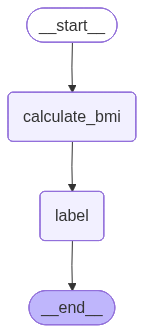

In [25]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())